## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


Epoch  1 | TrainLoss 0.6878 | ValLoss 0.6947 | Acc 0.5422 | Best 0.5422
Epoch  2 | TrainLoss 0.6264 | ValLoss 0.6773 | Acc 0.6281 | Best 0.6281
Epoch  3 | TrainLoss 0.5500 | ValLoss 0.6501 | Acc 0.6969 | Best 0.6969
Epoch  4 | TrainLoss 0.4926 | ValLoss 0.6141 | Acc 0.7328 | Best 0.7328
Epoch  5 | TrainLoss 0.4654 | ValLoss 0.5604 | Acc 0.7578 | Best 0.7578
Epoch  6 | TrainLoss 0.4307 | ValLoss 0.5080 | Acc 0.7656 | Best 0.7656
Epoch  7 | TrainLoss 0.4245 | ValLoss 0.4788 | Acc 0.7781 | Best 0.7781
Epoch  8 | TrainLoss 0.4039 | ValLoss 0.4428 | Acc 0.7922 | Best 0.7922
Epoch  9 | TrainLoss 0.4079 | ValLoss 0.4237 | Acc 0.8187 | Best 0.8187
Epoch 10 | TrainLoss 0.3999 | ValLoss 0.4109 | Acc 0.8203 | Best 0.8203
Epoch 11 | TrainLoss 0.3634 | ValLoss 0.3963 | Acc 0.8281 | Best 0.8281
Epoch 12 | TrainLoss 0.3512 | ValLoss 0.3828 | Acc 0.8313 | Best 0.8313
Epoch 13 | TrainLoss 0.3338 | ValLoss 0.3703 | Acc 0.8328 | Best 0.8328
Epoch 14 | TrainLoss 0.3537 | ValLoss 0.3702 | Acc 0.8297 | Best

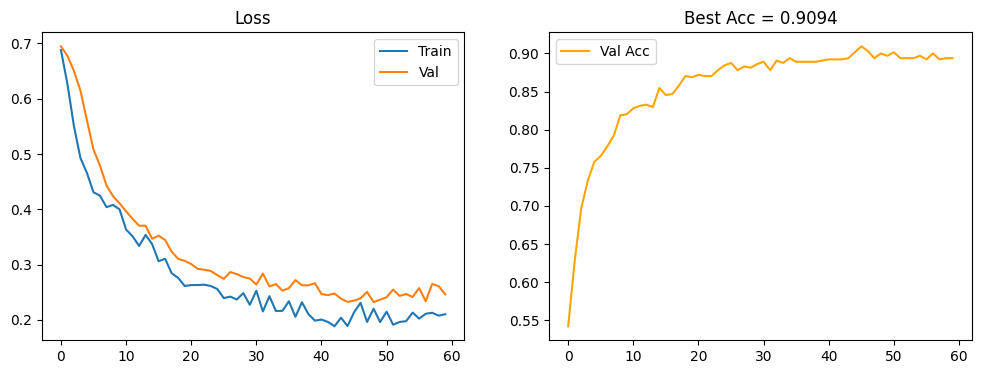

In [ ]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader


class EMA:
    def __init__(self, model, decay=0.99):
        self.model = model
        self.decay = decay
        self.shadow = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = self.decay * self.shadow[name] + (1 - self.decay) * param.data

    def get_ema_model(self):
        ema_model = type(self.model)()
        ema_model.load_state_dict(self.model.state_dict())
        for name, param in ema_model.named_parameters():
            if param.requires_grad:
                param.data = self.shadow[name]
        return ema_model


class TrainDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, "r") as f:
            self.x = torch.tensor(f["X"][()], dtype=torch.float32)
            self.y = torch.tensor(f["y"][()], dtype=torch.long)
        assert len(self.x) == len(self.y)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class TestDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, "r") as f:
            self.x = torch.tensor(f["X"][()], dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]

class EEGNet(nn.Module):
    def __init__(self, chans=20, time_point=200, f1=16, d=2, pk1=4, pk2=8, dp=0.5):
        super().__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(f1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, f1*d, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(f1*d),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(f1*d, f2, (1, 16), padding=(0, 8), groups=f2, bias=False),
            nn.Conv2d(f2, f2, 1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dp)
        )
        self.embed_dim = f2 * (time_point // pk1 // pk2)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(1)

class FinalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.eeg = EEGNet()
        self.fc = nn.Linear(self.eeg.embed_dim, 2)
    def forward(self, x):
        feat = self.eeg(x)
        return self.fc(feat)


BATCH_SIZE = 32
EPOCHS = 60
LR = 6e-4
WEIGHT_DECAY = 1e-4

INDEX_PATH_TRAIN = r"C:\Users\86159\Desktop\project\-2026--main\course_project\MDD\train.h5"
INDEX_PATH_VAL   = r"C:\Users\86159\Desktop\project\-2026--main\course_project\MDD\val.h5"
INDEX_PATH_TEST  = r"C:\Users\86159\Desktop\project\-2026--main\course_project\MDD\test_x_only.h5"

train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, 1, shuffle=False)

model = FinalModel()
ema = EMA(model, decay=0.99)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
val_losses = []
val_accs = []
best_acc = 0


for epoch in range(EPOCHS):
    model.train()
    t_loss = 0
    for x,y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        ema.update()
        t_loss += loss.item() * x.size(0)

    
    ema_model = ema.get_ema_model()
    ema_model.eval()
    v_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in val_loader:
            pred = ema_model(x)
            v_loss += criterion(pred, y).item() * x.size(0)
            correct += (pred.argmax(1) == y).sum().item()
            total += x.size(0)

    train_losses.append(t_loss / len(train_ds))
    val_losses.append(v_loss / len(val_ds))
    acc = correct / total
    val_accs.append(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(ema_model.state_dict(), "best_ema_model.pth")

    print(f"Epoch {epoch+1:2d} | TrainLoss {train_losses[-1]:.4f} | ValLoss {val_losses[-1]:.4f} | Acc {acc:.4f} | Best {best_acc:.4f}")
    scheduler.step()

# 预测
model.load_state_dict(torch.load("best_ema_model.pth"))
model.eval()
preds = []
with torch.no_grad():
    for x in test_loader:
        preds.append(model(x).argmax(1).item())

with open(r"C:\Users\86159\Desktop\project\-2026--main\course_project\MDD\test_preds.txt", "w") as f:
    for p in preds: f.write(f"{p}\n")

print("\n✅ 最终最佳验证准确率:", best_acc)
print("✅ test_preds.txt 已保存！")

# 绘图
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accs, label="Val Acc", color='orange')
plt.title(f"Best Acc = {best_acc:.4f}")
plt.legend()
plt.show()